# **Assignment 17: Forecasting Exchange Rates using Time Series Analysis (exchange_rate.csv)**

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### Part 1: Data Preparation and Exploration

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None

--- Missing Values Count ---
Ex_rate    0
dtype: int64


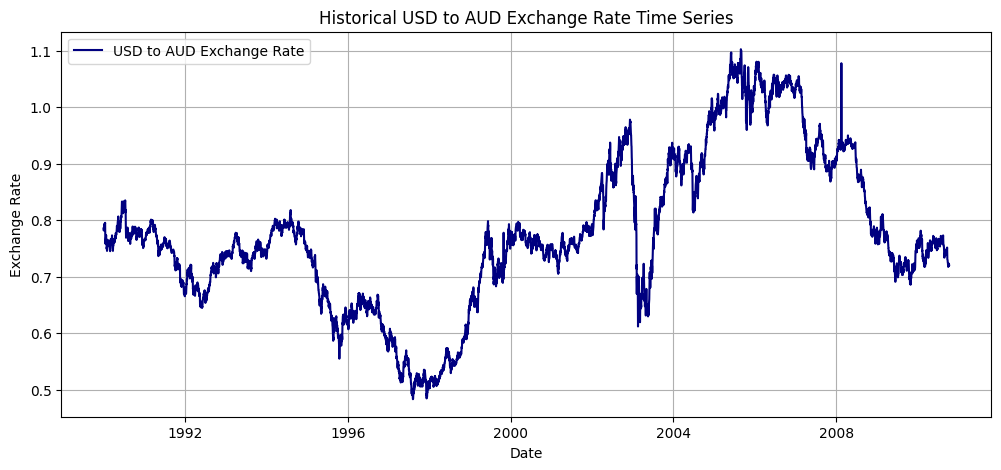

In [6]:
# Data Loading: Load exchange_rate.csv and parse date column
df_ex = pd.read_csv("/content/exchange_rate.csv")
df_ex["date"] = pd.to_datetime(df_ex["date"], format="%d-%m-%Y %H:%M")
df_ex = df_ex.sort_values("date").reset_index(drop=True)
df_ex.set_index("date", inplace=True)

print("--- Dataset Summary ---")
print(df_ex.info())

print("\n--- Missing Values Count ---")
print(df_ex.isnull().sum())

# Initial Exploration: Plot historical time series
plt.figure(figsize=(12, 5))
plt.plot(df_ex["Ex_rate"], label="USD to AUD Exchange Rate", color="navy")
plt.title("Historical USD to AUD Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.legend()
plt.show()

# Set frequency explicitly for time series modeling
df_ex = df_ex.asfreq("D")
df_ex["Ex_rate"] = df_ex["Ex_rate"].ffill()

**Part 2: Model Building - ARIMA & Exponential Smoothing**

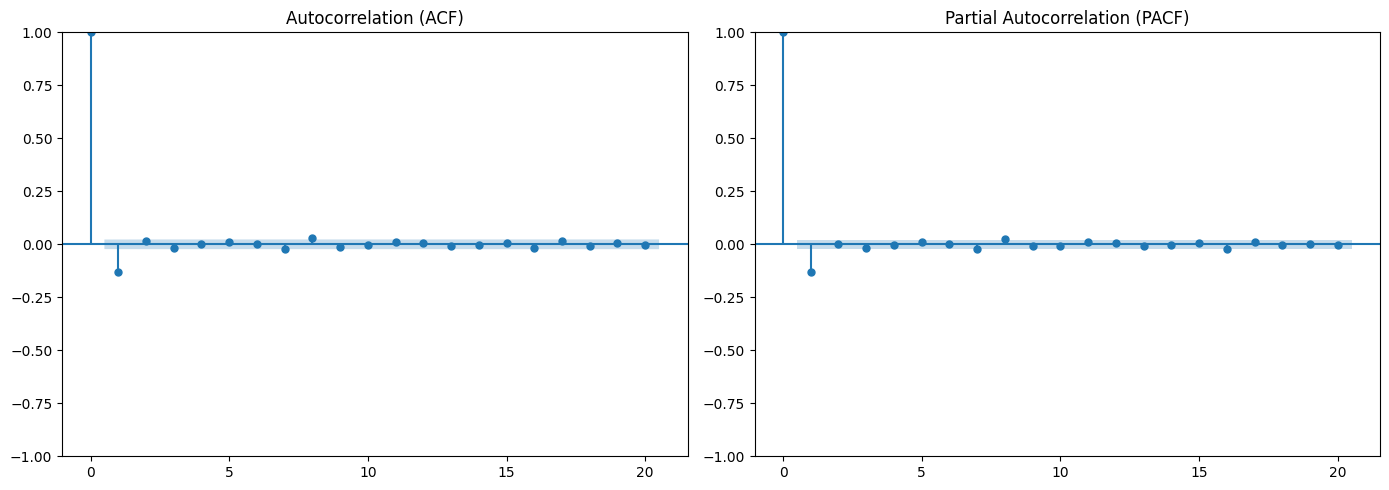

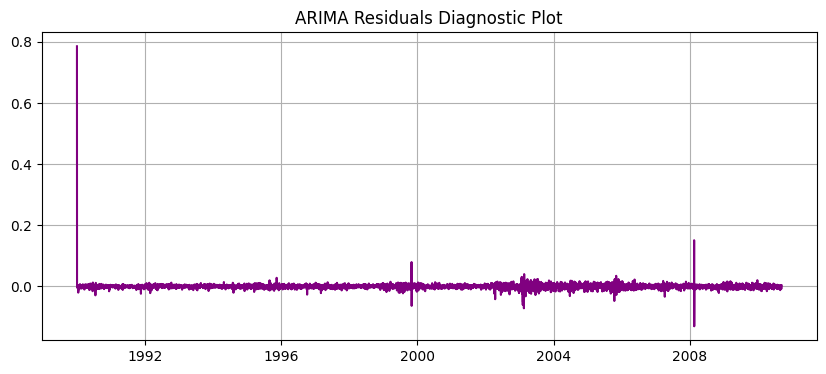

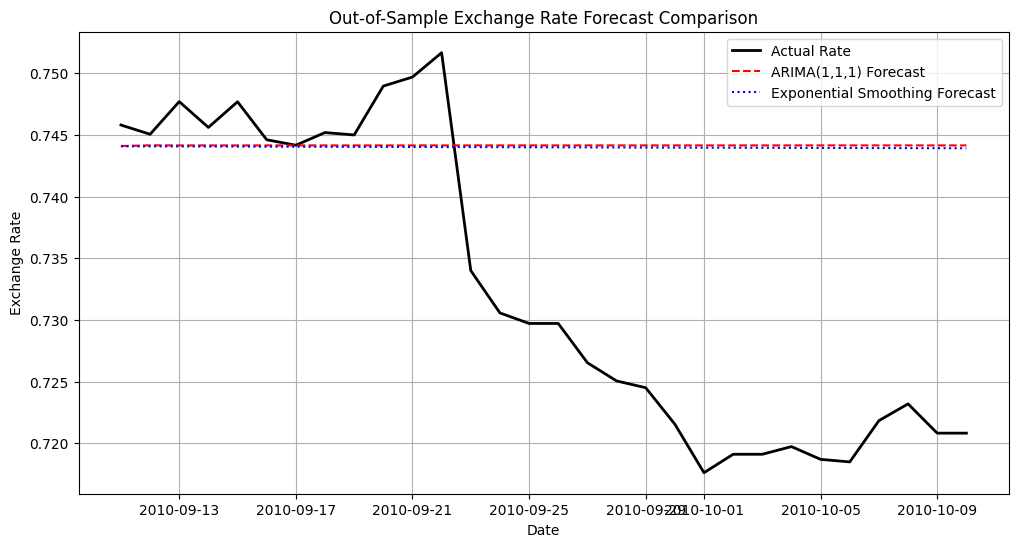

In [7]:
# Train-Test Split (Last 30 days retained for out-of-sample testing)
train = df_ex["Ex_rate"][:-30]
test = df_ex["Ex_rate"][-30:]

# ACF and PACF Plots for Parameter Selection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(train.diff().dropna(), ax=axes[0], lags=20, title="Autocorrelation (ACF)")
plot_pacf(
    train.diff().dropna(), ax=axes[1], lags=20, title="Partial Autocorrelation (PACF)"
)
plt.tight_layout()
plt.show()

# 1. Fit ARIMA Model (p=1, d=1, q=1)
model_arima = ARIMA(train, order=(1, 1, 1))
res_arima = model_arima.fit()
pred_arima = res_arima.forecast(steps=30)

# Residual Diagnostics for ARIMA
residuals_arima = res_arima.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals_arima, color="purple")
plt.title("ARIMA Residuals Diagnostic Plot")
plt.grid(True)
plt.show()

# 2. Fit Holt's Exponential Smoothing Model
model_exp = ExponentialSmoothing(train, trend="add", seasonal=None)
res_exp = model_exp.fit()
pred_exp = res_exp.forecast(steps=30)

# Out-of-sample Forecast Visualization
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label="Actual Rate", color="black", linewidth=2)
plt.plot(
    test.index,
    pred_arima,
    label="ARIMA(1,1,1) Forecast",
    color="red",
    linestyle="--",
)
plt.plot(
    test.index,
    pred_exp,
    label="Exponential Smoothing Forecast",
    color="blue",
    linestyle=":",
)
plt.title("Out-of-Sample Exchange Rate Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

**Part 3: Evaluation and Comparison**

In [8]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape


mae_arima, rmse_arima, mape_arima = calculate_metrics(test, pred_arima)
mae_exp, rmse_exp, mape_exp = calculate_metrics(test, pred_exp)

metrics_comparison = pd.DataFrame(
    [
        {
            "Model": "ARIMA(1,1,1)",
            "MAE": mae_arima,
            "RMSE": rmse_arima,
            "MAPE (%)": mape_arima,
        },
        {
            "Model": "Exponential Smoothing",
            "MAE": mae_exp,
            "RMSE": rmse_exp,
            "MAPE (%)": mape_exp,
        },
    ]
)

print("\n--- Error Metrics Evaluation ---")
print(metrics_comparison.to_string(index=False))


--- Error Metrics Evaluation ---
                Model      MAE     RMSE  MAPE (%)
         ARIMA(1,1,1) 0.013495 0.016632  1.863221
Exponential Smoothing 0.013423 0.016496  1.853156
